<span style="font-size:2em; font-weight:bold;"> Grenada Rainfall Analysis: Intensity Duration Frequency (IDF) Curve Development - Priors for Bayesian Inference</span>
***

In this code was develop the priors the Bayesian Inference Monte Carlo Markov Chain (MCMC) analysis of all rainfall stations for the both the Block Maxima (BM) and Peak-over-thresholds (POTS) extreme-value-analysis (EVA) methods. This is done by fitting all stations using the pyextremes Python package (https://georgebv.github.io/pyextremes) and understanding the distribution of each of the parameters to then develop a weakly informed prior.

# 1.0 Import Modules and data

## 1.1 Import modules

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
from pyextremes import EVA
from scipy import stats
import seaborn as sns

## 1.2 Import data

In [23]:
# station names and locations
stations = pd.read_excel(r'Data\GRN_RAINFALL_DATA_NAWASA_2025.xlsx',sheet_name='Raingauge Coordinates')

# imputed rainfall data
grn_rainfall_imput = pd.read_csv(r'Outputs\GRN_RAINFALL_MODELElev_FINAL_n6_thr25mm_var0p25.csv')
grn_rainfall_imput['date'] = pd.to_datetime(grn_rainfall_imput['date'], errors='coerce')
grn_rainfall_imput = grn_rainfall_imput.set_index('date').sort_index()

# get thresholds
pots_thr =  pd.read_csv(r'Outputs\pots_thresholds.csv')

# get station names from columns
station_ids = grn_rainfall_imput.columns.tolist()

# 2.0 Peaks-over-threshold (POTS) Extreme-value-analysis (EVA)

## 2.1 Single Station test

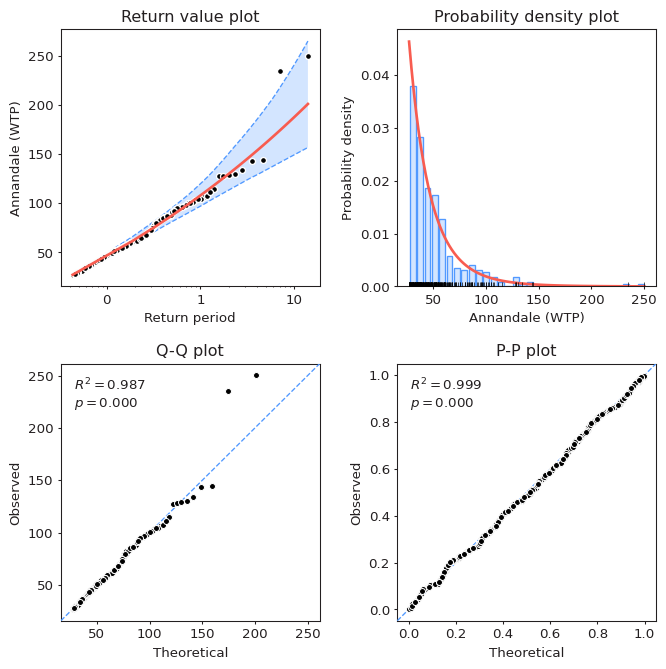

,return value,lower ci,upper ci
return period,,,
5.0,161,130,198
10.0,187,144,241
25.0,225,161,310
50.0,256,174,375
100.0,290,186,449


{'c': np.float64(0.10942945555512293), 'scale': np.float64(21.577401601754072)}


In [24]:
ts = grn_rainfall_imput[station_ids[0]].dropna()
model_POTS = EVA(ts)
model_POTS.get_extremes(method="POT", threshold = pots_thr[pots_thr.station_id==station_ids[0]].pots_thr.values[0])
model_POTS.fit_model(distribution="genpareto")
model_POTS.plot_diagnostic(alpha=0.95)
plt.show()

# show summary table of station fit information
summary_BM = model_POTS.get_summary(
  return_period=[5, 10, 25, 50, 100],
  alpha=0.95,
  n_samples=1000,
)
display(summary_BM.astype(np.int16))

# extract parameters
print(model_POTS.model.fit_parameters)

## 2.2 All stations

In [ ]:
rows = []
pooled_rows = []
for sta in station_ids:
    ts = grn_rainfall_imput[sta].dropna()

    model_POTS = EVA(ts)
    u = pots_thr.loc[pots_thr.station_id == sta, "pots_thr"].iloc[0]

    model_POTS.get_extremes(method="POT", threshold=u)
    model_POTS.fit_model(distribution="genpareto")

    fig, _ = model_POTS.plot_diagnostic(alpha=0.95)
    fig.savefig(
        rf"Outputs\PRIORS_POTS_BM\POTS_PLOTS\EVA_POT_{sta}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig)

    # fitted point estimates
    params = model_POTS.model.fit_parameters
    dist_name = model_POTS.model.distribution.name

    xi = params.get("c", 0.0)      # 0 for exponential case
    sigma = params["scale"]

    # Explicitly populate bootstrap cache for CI extraction
    _ = model_POTS.get_summary(
        return_period=[2],   # dummy RP just to trigger CI/bootstrap
        alpha=0.95,
        n_samples=1000
    )

    arr = np.asarray(model_POTS.model.fit_parameter_cache, dtype=float)

    # Parse bootstrap fits robustly
    if dist_name == "genpareto":
        if arr.shape[1] == 3:
            xi_all = arr[:, 0]
            sigma_all = arr[:, 2]
        elif arr.shape[1] == 2:
            xi_all = arr[:, 0]
            sigma_all = arr[:, 1]
        else:
            raise ValueError(f"Unexpected genpareto cache shape for {sta}: {arr.shape}")

        xi_5, xi_95 = np.percentile(xi_all, [2.5, 97.5])
        sigma_5, sigma_95 = np.percentile(sigma_all, [2.5, 97.5])

    elif dist_name == "expon":
        if arr.shape[1] == 2:
            sigma_all = arr[:, 1]
        elif arr.shape[1] == 1:
            sigma_all = arr[:, 0]
        else:
            raise ValueError(f"Unexpected expon cache shape for {sta}: {arr.shape}")

        xi_5, xi_95 = 0.0, 0.0
        sigma_5, sigma_95 = np.percentile(sigma_all, [2.5, 97.5])

    else:
        raise ValueError(f"Unexpected POT distribution for {sta}: {dist_name}")

    # store samples into a dataframe
    for xi_val, sigma_val in zip(xi_all, sigma_all):
        pooled_rows.append({
            "station_id": sta,
            "xi": xi_val,
            "sigma": sigma_val,
        })

    rows.append({
        "station": sta,
        "distribution": dist_name,
        "threshold": u,
        "xi": xi,
        "xi_5": xi_5,
        "xi_95": xi_95,
        "sigma": sigma,
        "sigma_5": sigma_5,
        "sigma_95": sigma_95,
    })

    print(f"Finished {sta}")
    plt.close('all')

POT_summary = pd.DataFrame(rows).set_index("station")
POTS_param_dist = pd.DataFrame(pooled_rows)
POTS_param_dist.to_csv(
    r"Outputs\PRIORS_POTS_BM\POTS_PARAM_DIST.csv",
    index=False
)
POT_summary.to_csv(
    r"Outputs\PRIORS_POTS_BM\POTS_PARAM_SUMMARY.csv",
    index=True
)

Finished Annandale (WTP)
Finished Bacolet III
Finished Blaize (TANK)
Finished Bon Accord (WTP)
Finished Brandon Hall (WTP)
Finished Chemin II
Finished Clozier (Tank)
Finished Concord (WTP)
Finished Dougaldston (WTP)
Finished Grand Etang (LAKE)
Finished Guapo
Finished Les Avocat (WTP)
Finished Mamma Cannes (WTP)
Finished Mardigras (WTP)
Finished Mirabeau (WTP)
Finished Mt Horne (WTP)
Finished Mt Reuil (WTP)
Finished Mt.Plaisir (WTP)
Finished Munich (WTP)
Finished Peggy's Whim (WTP)
Finished Petit Etang (WTP)


# 3.0 Block Maxima (BM) Extreme-value-analysis (EVA)

## 3.1 Single station test

In [ ]:
ts = grn_rainfall_imput[station_ids[0]].dropna()
model_BM = EVA(ts)
model_BM.get_extremes(method="BM", block_size="365.2425D", errors="coerce")
model_BM.fit_model(distribution="genextreme")
model_BM.plot_diagnostic(alpha=0.95)
plt.show()

# show summary table of station fit information
summary_BM = model_BM.get_summary(
  return_period=[5, 10, 25, 50, 100, 250, 500],
  alpha=0.95,
  n_samples=1000,
)

# extract parameters
print(model_BM.model.fit_parameters)

## 3.2 All stations

In [ ]:
rows = []
pooled_rows = []
summary_tables = {}

for sta in station_ids:
    ts = grn_rainfall_imput[sta].dropna()

    model_BM = EVA(ts)
    model_BM.get_extremes(
        method="BM",
        block_size="365.2425D",
        errors="coerce"
    )
    model_BM.fit_model(distribution="genextreme")

    # diagnostic plot
    fig, _ = model_BM.plot_diagnostic(alpha=0.95)
    fig.savefig(
        rf"Outputs\PRIORS_POTS_BM\BM_PLOTS\EVA_BM_{sta}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig)

    # return-level summary
    summary_BM = model_BM.get_summary(
        return_period=[5, 10, 25, 50, 100, 250, 500],
        alpha=0.95,
        n_samples=1000,
    )
    summary_tables[sta] = summary_BM.copy()

    # fitted point estimates
    params = model_BM.model.fit_parameters
    dist_name = model_BM.model.distribution.name

    xi = params.get('c', 0.0)          # GEV shape
    mu = params["loc"]        # GEV location
    sigma = params["scale"]   # GEV scale

    # bootstrap parameter cache
    arr = np.asarray(model_BM.model.fit_parameter_cache, dtype=float)

    if arr.shape[1] == 3:
        xi_all, mu_all, sigma_all = arr[:,0], arr[:,1], arr[:,2]
        xi_5, xi_95 = np.percentile(xi_all, 2.5), np.percentile(xi_all, 97.5)
        mu_5, mu_95 = np.percentile(mu_all, 2.5), np.percentile(mu_all, 97.5)
        sigma_5, sigma_95 = np.percentile(sigma_all, 2.5), np.percentile(sigma_all, 97.5)
    else:
        # Gumbel case: no xi, so fill with zeros
        xi_all = np.zeros(arr.shape[0])
        mu_all, sigma_all = arr[:,0], arr[:,1]
        xi_5, xi_95 = 0, 0
        mu_5, mu_95 = np.percentile(mu_all, 2.5), np.percentile(mu_all, 97.5)
        sigma_5, sigma_95 = np.percentile(sigma_all, 2.5), np.percentile(sigma_all, 97.5)

    # store samples into a dataframe
    for xi_val, sigma_val, mu_val in zip(xi_all, sigma_all, mu_all):
        pooled_rows.append({
            "station_id": sta,
            "xi": xi_val,
            "sigma": sigma_val,
            "mu": mu_val
        })

    rows.append({
        "station": sta,
        "xi": xi, "xi_5": xi_5, "xi_95": xi_95,
        "mu": mu, "mu_5": mu_5, "mu_95": mu_95,
        "sigma": sigma, "sigma_5": sigma_5, "sigma_95": sigma_95,
        "n_extremes": len(model_BM.extremes),
        "aic": model_BM.model.AIC,
        "dist": dist_name,
    })

    print(f"Finished {sta}")
    plt.close('all')

BM_param_summary = pd.DataFrame(rows).set_index("station")
BM_param_dist = pd.DataFrame(pooled_rows)
BM_param_dist.to_csv(
    r"C:\Users\LEGION\OneDrive\GRENADA_IDF_PROJECT\PRIORS_POTS_BM\BM_PARAM_DIST.csv",
    index=False
)
BM_param_summary.to_csv(
    r"C:\Users\LEGION\OneDrive\GRENADA_IDF_PROJECT\PRIORS_POTS_BM\BM_PARAM_SUMMARY.csv",
    index=True
)

# 3.0 Prior Distributions

## 3.1 POTS

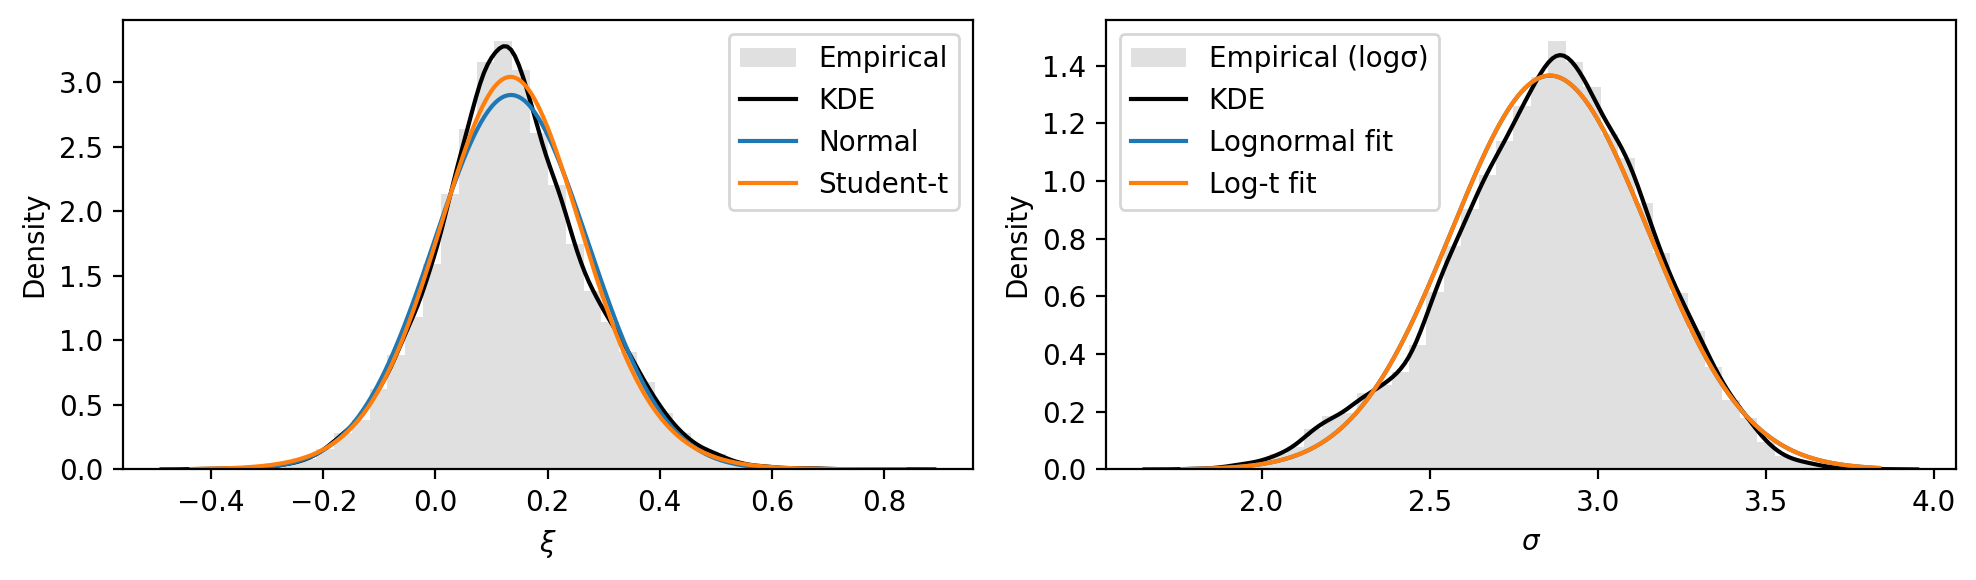

In [14]:
xi = POTS_param_dist["xi"].values
sigma = POTS_param_dist["sigma"].values
log_sigma = np.log(sigma)

fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=200)
ax[0].hist(xi, bins=40, density=True, alpha=0.4, color="0.7", label="Empirical")
sns.kdeplot(xi, ax=ax[0], color="k", label="KDE")

params_norm_xi = stats.norm.fit(xi)
params_t_xi    = stats.t.fit(xi)

xx = np.linspace(xi.min(), xi.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, *params_norm_xi), label="Normal")
ax[0].plot(xx, stats.t.pdf(xx, *params_t_xi), label="Student-t")
ax[0].legend()
ax[0].set_xlabel(r"$\xi$")

# σ distribution (log scale)
ax[1].hist(log_sigma, bins=40, density=True, alpha=0.4, color="0.7", label="Empirical (logσ)")
sns.kdeplot(log_sigma, ax=ax[1], color="k", label="KDE")

# Fit Normal and Student-t on log σ
params_norm_ls = stats.norm.fit(log_sigma)
params_t_ls    = stats.t.fit(log_sigma)

xx2 = np.linspace(log_sigma.min(), log_sigma.max(), 400)
ax[1].plot(xx2, stats.norm.pdf(xx2, *params_norm_ls), label="Lognormal fit")
ax[1].plot(xx2, stats.t.pdf(xx2, *params_t_ls), label="Log‑t fit")
ax[1].legend()
ax[1].set_xlabel(r"$\sigma$")

plt.tight_layout()
plt.show()

## 3.2 BM

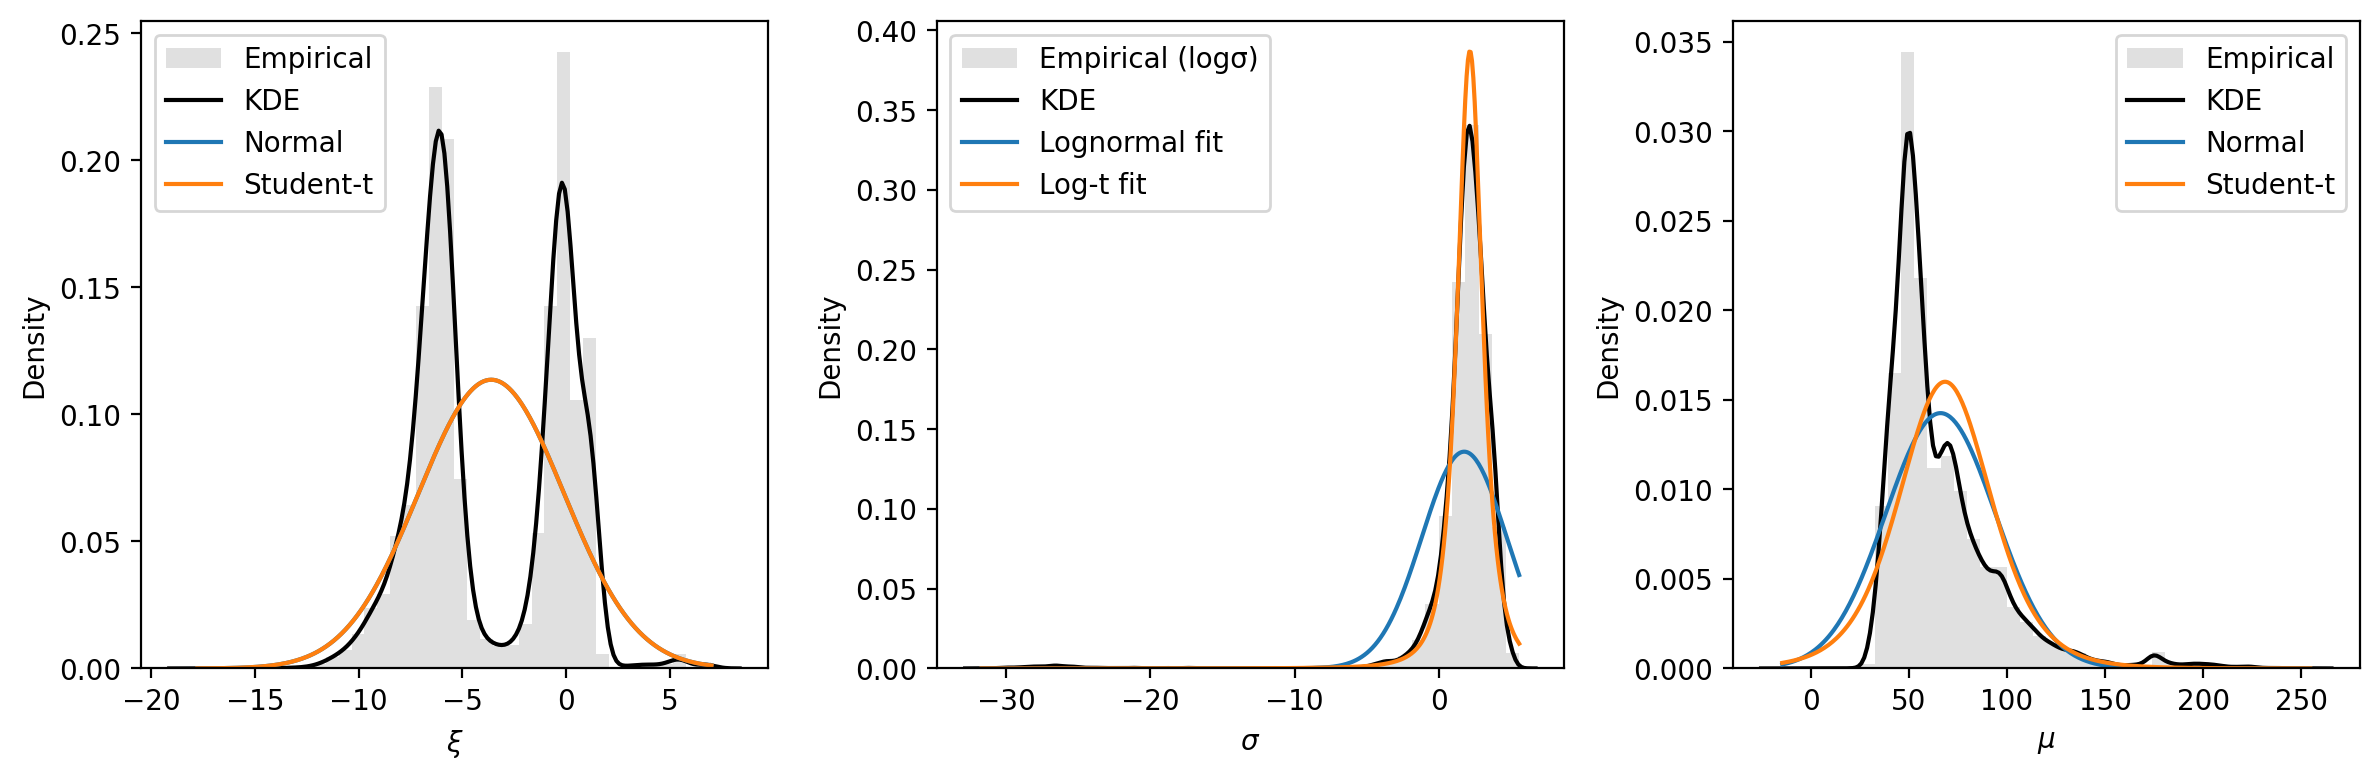

In [15]:
xi_BM     = BM_param_dist["xi"].values
sigma_BM  = BM_param_dist["sigma"].values
mu_BM     = BM_param_dist["mu"].values
log_sigma_BM = np.log(sigma_BM)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), dpi=200)

# xi (BM)
ax[0].hist(xi_BM, bins=40, density=True, alpha=0.4, color="0.7", label="Empirical")
sns.kdeplot(xi_BM, ax=ax[0], color="k", label="KDE")
params_norm_xi = stats.norm.fit(xi_BM)
params_t_xi    = stats.t.fit(xi_BM)
xx = np.linspace(xi_BM.min(), xi_BM.max(), 400)
ax[0].plot(xx, stats.norm.pdf(xx, *params_norm_xi), label="Normal")
ax[0].plot(xx, stats.t.pdf(xx, *params_t_xi), label="Student‑t")
ax[0].set_xlabel(r"$\xi$")
ax[0].legend()

# sigma (BM) — log scale
ax[1].hist(log_sigma_BM, bins=40, density=True, alpha=0.4, color="0.7", label="Empirical (logσ)")
sns.kdeplot(log_sigma_BM, ax=ax[1], color="k", label="KDE")
params_norm_ls = stats.norm.fit(log_sigma_BM)
params_t_ls    = stats.t.fit(log_sigma_BM)
xx2 = np.linspace(log_sigma_BM.min(), log_sigma_BM.max(), 400)
ax[1].plot(xx2, stats.norm.pdf(xx2, *params_norm_ls), label="Lognormal fit")
ax[1].plot(xx2, stats.t.pdf(xx2, *params_t_ls), label="Log‑t fit")
ax[1].set_xlabel(r"$\sigma$")
ax[1].legend()

# mi (BM)
ax[2].hist(mu_BM, bins=40, density=True, alpha=0.4, color="0.7", label="Empirical")
sns.kdeplot(mu_BM, ax=ax[2], color="k", label="KDE")
params_norm_mu = stats.norm.fit(mu_BM)
params_t_mu    = stats.t.fit(mu_BM)
xx3 = np.linspace(mu_BM.min(), mu_BM.max(), 400)
ax[2].plot(xx3, stats.norm.pdf(xx3, *params_norm_mu), label="Normal")
ax[2].plot(xx3, stats.t.pdf(xx3, *params_t_mu), label="Student‑t")
ax[2].set_xlabel(r"$\mu$")
ax[2].legend()
plt.tight_layout()
plt.show()

## 3.3 Check Prior fits

### 3.3.1 Function definition

In [16]:
def fit_and_score(dist, x, name, fixed_kwargs=None):
    fixed_kwargs = fixed_kwargs or {}
    # Fit distribution
    params = dist.fit(x, **fixed_kwargs)
    # Log-likelihood
    ll = np.sum(dist.logpdf(x, *params))
    k = len(params)
    n = len(x)
    aic = 2 * k - 2 * ll
    bic = k * np.log(n) - 2 * ll
    return {
        "name": name,
        "dist": dist,
        "params": params,
        "ll": ll,
        "aic": aic,
        "bic": bic,
    }


### 3.3.2 POTS Fits

#### 3.3.3.2.1 $\sigma$

In [17]:
sigma = POTS_param_dist["sigma"].values
log_sigma = np.log(sigma)

results_sigma = []

# Lognormal: Normal on log σ
res_lognorm = fit_and_score(stats.norm, log_sigma, name="Lognormal (via log σ)")
results_sigma.append(res_lognorm)

# Log‑t: Student‑t on log σ
res_logt = fit_and_score(stats.t, log_sigma, name="Log‑t (via log σ)")
results_sigma.append(res_logt)

# Gamma on σ
res_gamma = fit_and_score(stats.gamma, sigma, name="Gamma")
results_sigma.append(res_gamma)

# Inverse‑Gamma on σ
res_invgamma = fit_and_score(stats.invgamma, sigma, name="Inverse‑Gamma")
results_sigma.append(res_invgamma)

# Rank by AIC / BIC
results_sigma_sorted = sorted(results_sigma, key=lambda d: d["aic"])
for r in results_sigma_sorted:
    print(f"{r['name']}: AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

Lognormal (via log σ): AIC=10586.5, BIC=10603.0
Log‑t (via log σ): AIC=10588.5, BIC=10613.2
Gamma: AIC=170278.5, BIC=170303.2
Inverse‑Gamma: AIC=170325.0, BIC=170349.8


#### 3.3.3.2.2 $\xi$

In [18]:
xi = POTS_param_dist["xi"].values

results_xi = []

# Normal
res_norm = fit_and_score(stats.norm, xi, name="Normal")
results_xi.append(res_norm)

# Student‑t
res_t = fit_and_score(stats.t, xi, name="Student‑t")
results_xi.append(res_t)

# Skew‑normal (optional)
res_skew = fit_and_score(stats.skewnorm, xi, name="Skew‑normal")
results_xi.append(res_skew)

# Rank by AIC
results_xi_sorted = sorted(results_xi, key=lambda d: d["aic"])
for r in results_xi_sorted:
    print(f"{r['name']}: AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

Student‑t: AIC=-31770.3, BIC=-31745.6
Skew‑normal: AIC=-31740.4, BIC=-31715.7
Normal: AIC=-31639.0, BIC=-31622.5


### 3.3.3 BM fits

#### 3.3.3.1 $\mu$

In [19]:
mu_BM = BM_param_dist["mu"].values

results_mu = []

# Normal
res_norm_mu = fit_and_score(stats.norm, mu_BM, name="Normal")
results_mu.append(res_norm_mu)

# Student‑t
res_t_mu = fit_and_score(stats.t, mu_BM, name="Student‑t")
results_mu.append(res_t_mu)

# Gamma (μ is positive)
res_gamma_mu = fit_and_score(stats.gamma, mu_BM, name="Gamma")
results_mu.append(res_gamma_mu)

# Inverse‑Gamma
res_invgamma_mu = fit_and_score(stats.invgamma, mu_BM, name="Inverse‑Gamma")
results_mu.append(res_invgamma_mu)

# Rank by AIC
results_mu_sorted = sorted(results_mu, key=lambda d: d["aic"])
for r in results_mu_sorted:
    print(f"{r['name']}: AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

Inverse‑Gamma: AIC=252386.6, BIC=252411.4
Student‑t: AIC=262396.3, BIC=262421.0
Normal: AIC=266031.9, BIC=266048.4
Gamma: AIC=inf, BIC=inf


#### 3.3.3.2 $\sigma$

In [20]:
sigma_BM = BM_param_dist["sigma"].values
log_sigma_BM = np.log(sigma_BM)

results_sigma_BM = []

# Lognormal: Normal on log σ
res_lognorm_BM = fit_and_score(stats.norm, log_sigma_BM, name="Lognormal (via log σ)")
results_sigma_BM.append(res_lognorm_BM)

# Log‑t: Student‑t on log σ
res_logt_BM = fit_and_score(stats.t, log_sigma_BM, name="Log‑t (via log σ)")
results_sigma_BM.append(res_logt_BM)

# Gamma on σ
res_gamma_BM = fit_and_score(stats.gamma, sigma_BM, name="Gamma")
results_sigma_BM.append(res_gamma_BM)

# Inverse‑Gamma on σ
res_invgamma_BM = fit_and_score(stats.invgamma, sigma_BM, name="Inverse‑Gamma")
results_sigma_BM.append(res_invgamma_BM)

# Rank by AIC
results_sigma_BM_sorted = sorted(results_sigma_BM, key=lambda d: d["aic"])
for r in results_sigma_BM_sorted:
    print(f"{r['name']}: AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

Log‑t (via log σ): AIC=100273.5, BIC=100298.3
Lognormal (via log σ): AIC=139767.8, BIC=139784.3
Inverse‑Gamma: AIC=206754.2, BIC=206778.9
Gamma: AIC=427848.3, BIC=427873.0


#### 3.3.3.3 $\xi$

In [21]:
xi_BM = BM_param_dist["xi"].values

results_xi_BM = []

# Normal
res_norm_xi_BM = fit_and_score(stats.norm, xi_BM, name="Normal")
results_xi_BM.append(res_norm_xi_BM)

# Student‑t
res_t_xi_BM = fit_and_score(stats.t, xi_BM, name="Student‑t")
results_xi_BM.append(res_t_xi_BM)

# Skew‑normal
res_skew_xi_BM = fit_and_score(stats.skewnorm, xi_BM, name="Skew‑normal")
results_xi_BM.append(res_skew_xi_BM)

# Rank by AIC
results_xi_BM_sorted = sorted(results_xi_BM, key=lambda d: d["aic"])
for r in results_xi_BM_sorted:
    print(f"{r['name']}: AIC={r['aic']:.1f}, BIC={r['bic']:.1f}")

Skew‑normal: AIC=149772.8, BIC=149797.5
Normal: AIC=149778.6, BIC=149795.1
Student‑t: AIC=149780.6, BIC=149805.3
